# Toy Example of SBI in Population Genetics

Based on the knowledge about `sbi` and simulating populations using `msprime`, in this notebook we apply simulation-based inference to infer **two** effective population sizes `Ne_1` and `Ne_2` (a single population whose size changes from the ancient value `Ne_2` to the recent value `Ne_1` at a fixed time point) from the **folded site-frequency spectrum (SFS)** of simulated DNA sequences.

A note on what "jointly inferring" means in SBI: **NPE infers exactly the parameters you randomize in the simulator, no more, no less.** Here we draw `(Ne_1, Ne_2)` from the prior for every simulation, so the network learns a joint posterior over both. The recombination and mutation rates are held **fixed** inside the simulator, so they are constants of the model rather than inferred quantities. If you wanted to infer the recombination rate as well, you would add it to the prior and let it vary across simulations. This is exactly what the pipeline in notebook 5 does.

Although real applications would use more sophisticated summary statistics, this toy example demonstrates the whole workflow.

## Learning goals

After this notebook we should be able to:

- wrap an `msprime` simulation into an `sbi` compatible simulator that returns summary statistics;
- put a prior on the **log10 scale** for scale parameters like `Ne`, and explain why;
- train NPE on $(\theta, x)$ pairs and inspect the loss curves;
- judge posterior quality with a pairplot, posterior predictive checks, and SBC, and name at least three reasons a posterior can be poor (simulation budget, weakly informative summaries, parameter non-identifiability).

In [1]:
import torch
from sbi.inference import NPE
from sbi.utils import BoxUniform
import msprime
import numpy as np
import matplotlib.pyplot as plt
from sbi.analysis import pairplot
from sbi.diagnostics import run_sbc,check_sbc
from sbi.analysis.plot import sbc_rank_plot
from sbi.analysis import plot_summary


## Model simulation
We assume a single population evolving under the neutral coalescent. Chromosomes are simulated with length 1 Mb, a fixed mutation rate and recombination rate.

The simulator function takes $\theta = (\log_{10} N_{e1}, \log_{10} N_{e2})$ as input, back-transforms to $N_e$ values, and returns the folded SFS as a summary statistic. Each $\log_{10} N_e$ is drawn from a uniform distribution. See the prior section below for why we work on the log scale. (This is not a realistic scenario!) 
> Note that when simulating populations using `msprime`, the time of effective population size changes should be defined as well. In this case, we simply say that the change happens 100 generations ago.

Again, we use `msprime` to simulate the tree sequence, and extract the folded SFS using the `tskit` function.

In [2]:
def simulator(theta):
    """
    input: theta: tensor of shape (num_simulations, num_parameters), holding log10(Ne) values
    output: s_stats: tensor of shape (num_simulations, num_summary_statistics)
    """
    s_stats = []
    for log10_ne in theta.tolist():
        ne = [10 ** v for v in log10_ne]  # back-transform: the prior lives on the log10 scale
        ts = simulate_constant_population(sequence_length=1e6, ne=ne, samples=10, recomb_rate=1e-9, mutation_rate=1e-7)
        s = ts.allele_frequency_spectrum(polarised=False) # returns folded SFS. Set polarised=True to use unfolded SFS
        s_stats.append(s)
    return torch.tensor(s_stats, dtype=torch.float32)

def simulate_constant_population(sequence_length, ne, samples, recomb_rate, mutation_rate):
    # Define demography
    demography = msprime.Demography()
    demography.add_population(initial_size=ne[0])
    for i in range(1, len(ne)):
                demography.add_population_parameters_change(
                    initial_size=ne[i], time=i * 100
                )

    # Simulate ancestry and mutations
    ts_anc = msprime.sim_ancestry(samples=samples,
                                recombination_rate=recomb_rate,
                                sequence_length=sequence_length,
                                demography=demography)
    ts = msprime.sim_mutations(ts_anc, rate=mutation_rate)

    return ts


Note that `times` are **backward** in msprime: time=0 is now, larger times are further in the past. The window labels might feel reversed in population with effective population size changes.

## Prior distribution and training data

`Ne` is a *scale* parameter: values 100 and 1,000 differ as much, biologically, as 10,000 and 100,000. A uniform prior on the raw scale would spend almost all of its mass on huge populations (half of all draws above 50,000) and would almost never propose small ones. The standard practice is therefore a **log-uniform prior**: uniform on $\log_{10} N_e$.

We place $\log_{10} N_e \sim U(1, 5)$ for each epoch, i.e. `Ne` ranges from 10 to 100,000, and the simulator back-transforms with $10^\theta$.

In [3]:
# Prior over log10(Ne): uniform on [1, 5]  <=>  Ne between 10 and 1e5
num_Ne = 2
prior = BoxUniform(low=1.0 * torch.ones(num_Ne), high=5.0 * torch.ones(num_Ne))

# Generate training data
num_simulations = 200
theta = prior.sample((num_simulations,))
# theta

In [4]:
x = simulator(theta)
# x

/var/folders/k5/fxhm2ffn0vz3vy1__6s7lhn80000gp/T/ipykernel_22982/2545953487.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:255.)
  return torch.tensor(s_stats, dtype=torch.float32)


## Training Model


In [5]:
# Train NPE
inference = NPE(prior=prior)
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

/Users/yuxinning/miniconda3/envs/sbi-workshop/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has constant values in dimension(s) [0, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 298 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/yuxinning/Projects/SBI_ECCB2026/sbi-logs/NPE_C/2026-08-17T20_10_47.238629' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


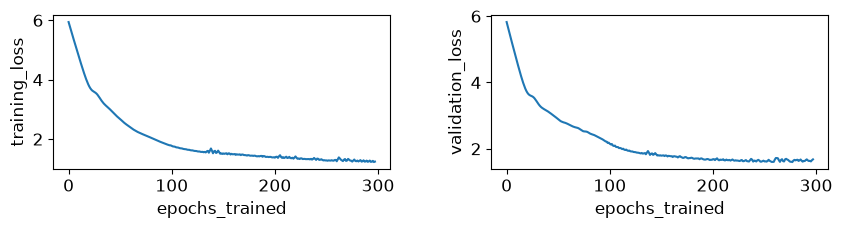

In [6]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

## Test dataset
After the network got trained, we want to investigate the results. We can sample again from the prior to get an independent test dataset.

In [7]:
test_theta = prior.sample((1,)) 
x_o = simulator(test_theta).squeeze()
samples = posterior.sample((10000,), x=x_o)

  0%|          | 0/10000 [00:00<?, ?it/s]

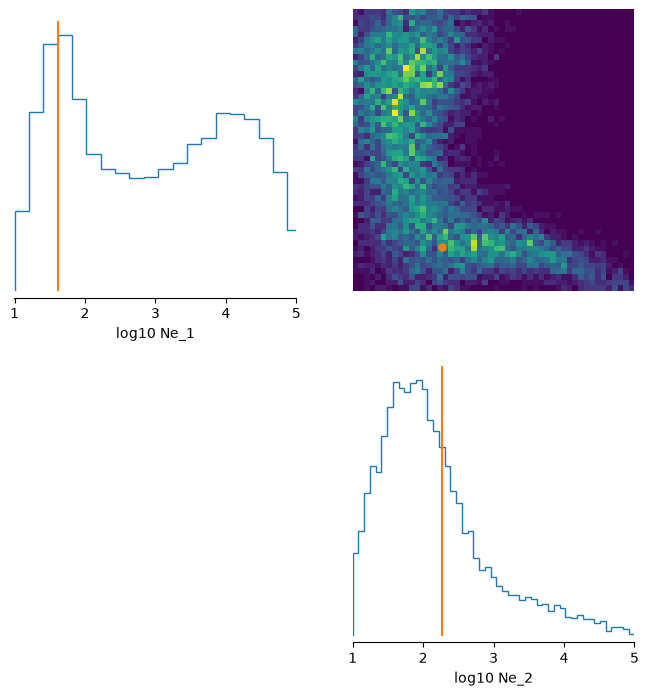

In [8]:
limit = [[1, 5]] * num_Ne
labels = [f"log10 Ne_{i+1}" for i in range(num_Ne)]
_ = pairplot(
    samples,
    points=test_theta,
    limits=limit,
    figsize=(8, 8),
    labels=labels,
)

From the visualization, we can see how well the posterior samples (blue) cover the ground truth (orange).

***Try a few different test draws (re-run the two cells above) and compare.***

**What to expect:** with only 200 training simulations the posterior will typically be broad, and its quality will vary noticeably between test draws, sometimes one parameter is well-constrained while the other is nearly unconstrained. Which of the two `Ne` values is better constrained depends on the drawn scenario (e.g., a very small recent `Ne_1` erases most of the older signal), so don't be surprised if your plot disagrees with your neighbour's. Reasons the network may struggle here:
- too little training data (200 simulations is deliberately tiny — try 1,000 and compare);
- the folded SFS may carry little information about the older epoch (information loss from summarizing);
- the two epochs can partially trade off against each other (non-identifiability).

You may come up with more directions to explore this scenario!

## Posterior predictive checks

In [26]:
posterior_samples = posterior.sample((10,), x=x_o)
posterior_predictives = simulator(posterior_samples)

  0%|          | 0/10 [00:00<?, ?it/s]

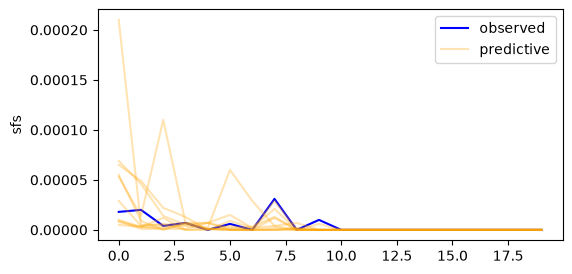

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
_ = ax.plot(x_o[1:], c='blue')
for i in range(10): 
    _ = ax.plot(posterior_predictives[i][1:], alpha=0.3, c='orange')
_ = ax.legend(["observed", "predictive"])
_ = ax.set_ylabel("sfs")
_ = plt.show()

The summary statistics from the posterior samples are quite similar to the observed datum, which means our inference is likely **not wrong**.

## Simulation-Based Calibration

**What to expect:** with such a small training budget the rank histograms may show mild deviations from uniformity. If you increase `num_simulations` and retrain, the histograms should flatten.

In [11]:
num_sbc_runs = 100  # choose a number of sbc runs, should be ~100s
theta_o_i = prior.sample((num_sbc_runs,))
x_o_i = simulator(theta_o_i)

In [12]:
num_posterior_samples = 1000
ranks, dap_samples = run_sbc(
    theta_o_i,
    x_o_i,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)

Sampling 100 times (1000,) posterior samples.: 100%|██████████| 100/100 [00:01<00:00, 91.34it/s]


Calculating ranks for 100 SBC samples:   0%|          | 0/100 [00:00<?, ?it/s]

One check provided by the `sbi` package is shown below. The `check_stats` variable contains a dictionary with 3 metrics that help to judge our posterior. The “first” two compare the ranks to a uniform distribution. 

You can find more about [KS test](https://en.wikipedia.org/wiki/Kolmogorov–Smirnov_test#Two-sample_Kolmogorov–Smirnov_test) and [c2st test](https://arxiv.org/abs/1610.06545).

In [13]:
check_stats = check_sbc(ranks, theta_o_i, dap_samples, 1_000)
print(
    f"""kolmogorov-smirnov p-values \n
    check_stats['ks_pvals'] = {check_stats['ks_pvals'].numpy()}"""
)
print("\n")

kolmogorov-smirnov p-values 

    check_stats['ks_pvals'] = [0.12518957 0.39793262]




The Kolmogorov-Smirnov (KS test) returns p-values on the null hypothesis that the samples from `ranks` are drawn from a uniform distribution. Our problem is two-dimensional, so one p-value for each dimension is provided.

The null hypothesis (of both distributions being equal) is rejected if the p-values fall below a significance threshold (usually < `0.05`). 

Therefore, the values we see here should ideally be much larger than `0.05` because the ranks should ideally be close to a uniform distribution. If they are below `0.05` then this indicates that the posterior is not well-calibrated. 

> Note, however, that we can obtain arbitrarily small p-values if we use a large number of samples, (`num_sbc_runs`). Note also that this is only a necessary check, i.e., we can only conclude that the posterior is not miscalibrated, not that it is accurate.


In [14]:
print(
    f"""c2st accuracies \n
    check_stats['c2st_ranks'] = {check_stats['c2st_ranks'].numpy()}"""
)

c2st accuracies 

    check_stats['c2st_ranks'] = [0.49  0.495]


The second c2st test compares `ranks` with a uniform distributions. This is a nonparametric two sample test based on training a classifier to differentiate two ensembles. 

Here, these two ensembles are the observed `ranks` and samples from a uniform distribution. The values reported are the accuracies from n-fold cross-validation. 

If you see values around `0.5`, the classifier was unable to differentiate both ensembles, i.e. `ranks` are very uniform. If the values are high towards `1`, this matches the case where `ranks` is very unlike a uniform distribution.

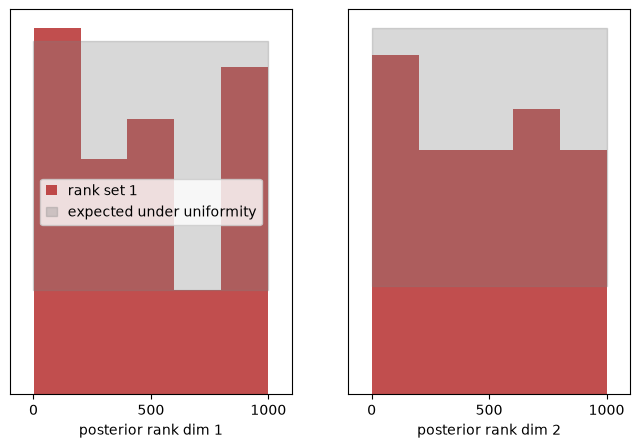

In [28]:
fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    plot_type="hist",
    num_bins=5
)